In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df = df.dropna(subset=["TotalCharges"])
df.reset_index(drop=True, inplace=True)


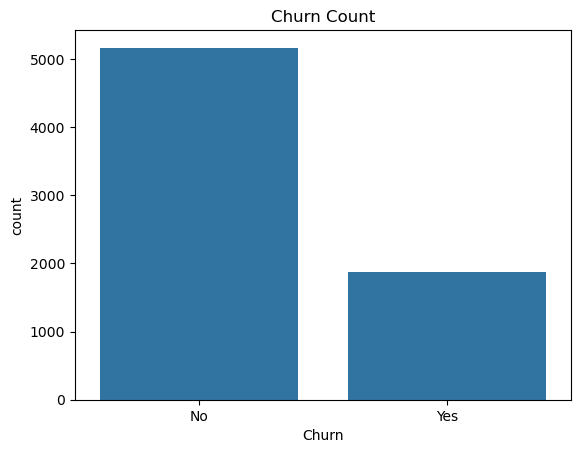

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Churn Count")
plt.show()


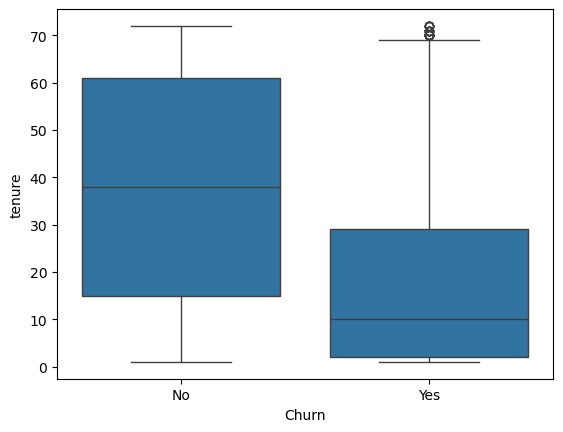

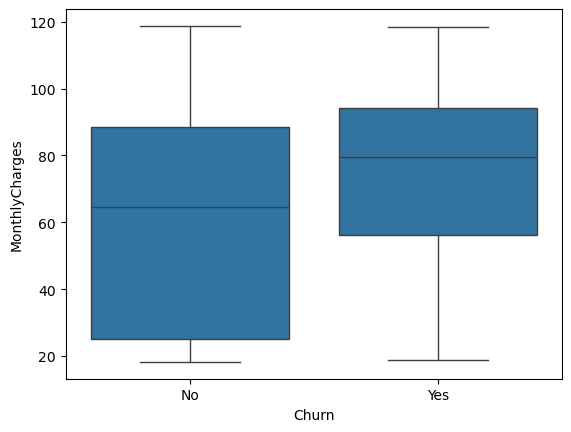

In [5]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()


In [6]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})


In [7]:
df = pd.get_dummies(df, drop_first=True)


In [8]:
def tenure_group(tenure):
    if tenure <= 12:
        return "0-1 Year"
    elif tenure <= 24:
        return "1-2 Years"
    elif tenure <= 48:
        return "2-4 Years"
    elif tenure <= 60:
        return "4-5 Years"
    else:
        return "5+ Years"

df["tenure_group"] = df["tenure"].apply(tenure_group)
df = pd.get_dummies(df, columns=["tenure_group"], drop_first=True)


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 'customerID' column already removed by get_dummies
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop customerID if still there
df = df.drop("customerID", axis=1, errors='ignore')

# Split features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

# Decision Tree
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)
tree_preds = tree_model.predict(X_test)


In [13]:
def evaluate_model(name, y_true, y_pred):
    print(f"📊 Results for {name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    print("-" * 50)

evaluate_model("Logistic Regression", y_test, log_preds)
evaluate_model("Decision Tree", y_test, tree_preds)


📊 Results for Logistic Regression
Accuracy: 0.7860696517412935
Confusion Matrix:
 [[990  43]
 [258 116]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.96      0.87      1033
           1       0.73      0.31      0.44       374

    accuracy                           0.79      1407
   macro avg       0.76      0.63      0.65      1407
weighted avg       0.78      0.79      0.75      1407

--------------------------------------------------
📊 Results for Decision Tree
Accuracy: 0.7526652452025586
Confusion Matrix:
 [[875 158]
 [190 184]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83      1033
           1       0.54      0.49      0.51       374

    accuracy                           0.75      1407
   macro avg       0.68      0.67      0.67      1407
weighted avg       0.75      0.75      0.75      1407

-------------------------------------------

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)


In [15]:
# Install XGBoost if needed
%pip install xgboost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)


c:\Users\mnmoh\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:09:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [16]:
evaluate_model("Random Forest", y_test, rf_preds)
evaluate_model("XGBoost", y_test, xgb_preds)


📊 Results for Random Forest
Accuracy: 0.7882018479033405
Confusion Matrix:
 [[947  86]
 [212 162]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.86      1033
           1       0.65      0.43      0.52       374

    accuracy                           0.79      1407
   macro avg       0.74      0.67      0.69      1407
weighted avg       0.77      0.79      0.77      1407

--------------------------------------------------
📊 Results for XGBoost
Accuracy: 0.775408670931059
Confusion Matrix:
 [[902 131]
 [185 189]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.51      0.54       374

    accuracy                           0.78      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407

--------------------------------------------------


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)


In [18]:
# Install XGBoost if needed
# !pip install xgboost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)


c:\Users\mnmoh\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:10:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
